In [27]:
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
from src.MBT import mean_below_threshold as mbt

In [2]:
wind = xr.open_dataset("data/processed/daily-state-cf/wind_daily-state-cf.nc")
solar = xr.open_dataset("data/processed/daily-state-cf/solar_daily-state-cf.nc")

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [10]:
wind_winter = wind.sel(time=wind.time.dt.month.isin([6, 7, 8]))
solar_winter = solar.sel(time=solar.time.dt.month.isin([6, 7, 8]))

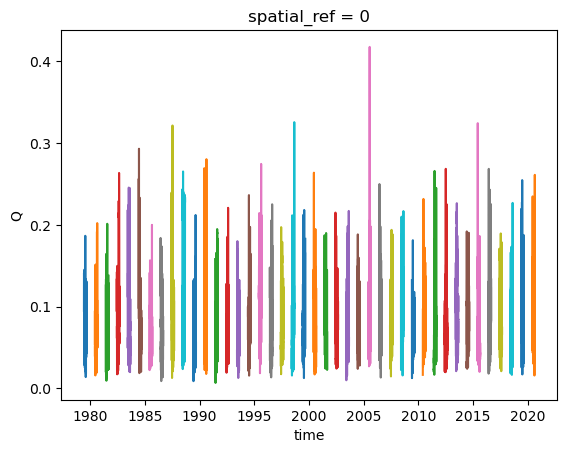

In [11]:
for year in range(1979, 2021):
    wind_winter.sel(time=f"{year}").Q.plot()

In [98]:
# get thresholds using 10th percentile for each state

threshold_percentile = 0.1
thresholds = {}

# for wind threshold, use all data,
# for solar only use winter data
for state in wind.data_vars:
    thresholds[f"solar_{state}"] = solar_winter[state].quantile(threshold_percentile).item()
    thresholds[f"wind_{state}"] = wind[state].quantile(threshold_percentile).item()

In [99]:
thresholds

{'solar_Q': 0.12859422266483309,
 'wind_Q': 0.030083213932812214,
 'solar_N': 0.09107748940587043,
 'wind_N': 0.034490831196308136,
 'solar_V': 0.06676724776625634,
 'wind_V': 0.04026288539171219,
 'solar_S': 0.08736495971679688,
 'wind_S': 0.044248128309845924,
 'solar_T': 0.052090673521161084,
 'wind_T': 0.031058729626238346}

In [100]:
results = {}

for state in ["Q", "N", "V", "S"]:
    solar_threshold = thresholds[f"solar_{state}"]
    wind_threshold = thresholds[f"wind_{state}"]

    for year in range(1979, 2024):
        
        solar_data = solar_winter[state].sel(time=f"{year}")
        wind_data = wind_winter[state].sel(time=f"{year}")
    
        solar_lulls = mbt(
            data=solar_data,
            threshold=solar_threshold,
            length_max=90,
            length_min=3
        )
        wind_lulls = mbt(
            data=wind_data,
            threshold=wind_threshold,
            length_max=90,
            length_min=3
        )

        # get max length of lulls
        valid_solar = solar_lulls.any("time").where(lambda x: x, drop=True)
        max_solar = 0 if valid_solar.sizes["length"] == 0 else valid_solar.length.max().item()
        
        valid_wind = wind_lulls.any("time").where(lambda x: x, drop=True)
        max_wind = 0 if valid_wind.sizes["length"] == 0 else valid_wind.length.max().item()

        # number of lull days
        total_solar = solar_lulls.any("length").sum('time').item()
        total_wind = wind_lulls.any("length").sum('time').item()

        # compound events
        compound_lulls = (solar_lulls.any("length") & wind_lulls.any("length")).sum().item()
        
        if year == 1979:
            results[f'longest_solar_{state}'] = [max_solar]
            results[f'longest_wind_{state}'] = [max_wind]

            results[f"total_solar_{state}"] = [total_solar]
            results[f"total_wind_{state}"] = [total_wind]

            results[f"total_compound_{state}"] = [compound_lulls]
            
            
        else:
            results[f'longest_solar_{state}'].append(max_solar)
            results[f'longest_wind_{state}'].append(max_wind)

            results[f"total_solar_{state}"].append(total_solar)
            results[f"total_wind_{state}"].append(total_wind)

            results[f"total_compound_{state}"].append(compound_lulls)

    print(state)

Q
N
V
S


In [101]:
df = pd.DataFrame(results, index=range(1979, 2024))

In [102]:
region_colors = {
    "Q": "tab:blue",
    "N": "tab:orange",
    "V": "tab:green",
    "S": "tab:red",
}
def get_region(col):
    return col.split("_")[-1]

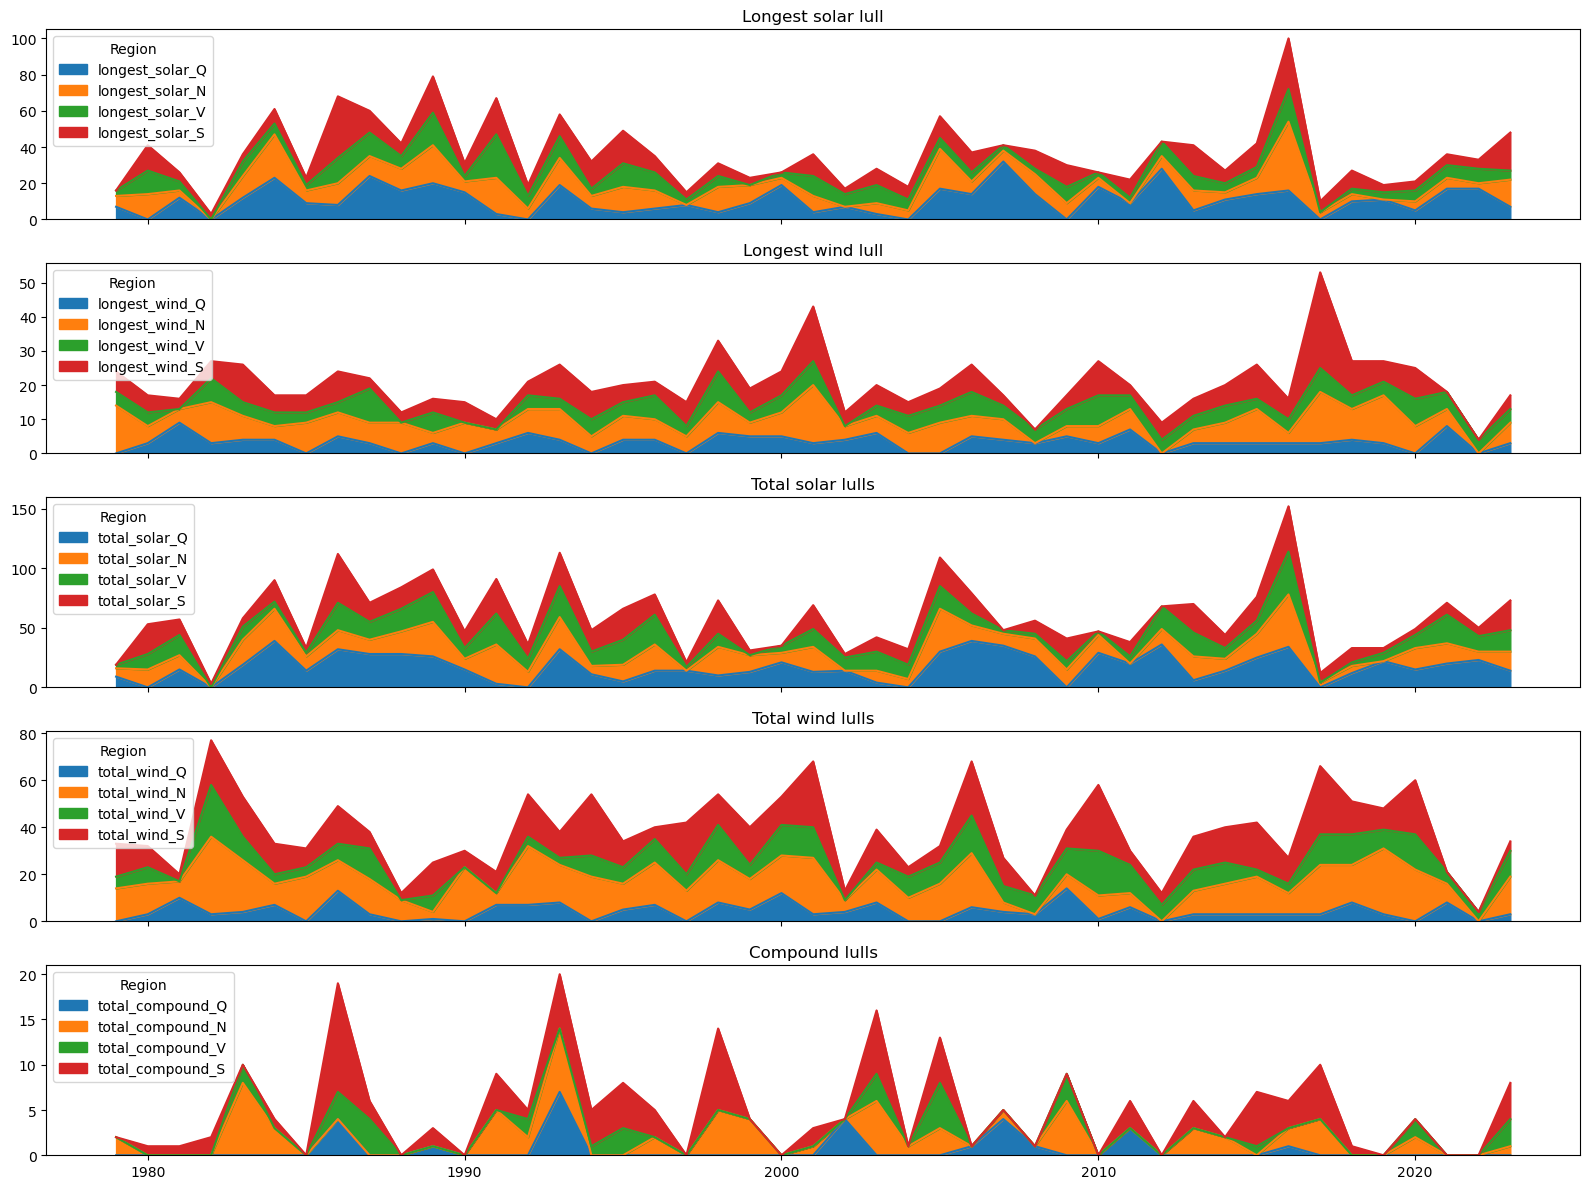

In [119]:
regions = ["Q", "N", "V", "S"]

colors = {
    "Q": "tab:blue",
    "N": "tab:orange",
    "V": "tab:green",
    "S": "tab:red",
}

metrics = [
    ("longest_solar", "Longest solar lull"),
    ("longest_wind", "Longest wind lull"),
    ("total_solar", "Total solar lulls"),
    ("total_wind", "Total wind lulls"),
    ("total_compound", "Compound lulls"),
]

fig, axes = plt.subplots(
    nrows=len(metrics),
    ncols=1,
    figsize=(16, 12),
    sharex=True,
)

for ax, (metric, title) in zip(axes, metrics):
    cols = [f"{metric}_{r}" for r in regions]

    df[cols].plot.area(
        ax=ax,
        color=[colors[r] for r in regions],
    )

    ax.set_title(title)
    ax.legend(title="Region", loc="upper left")

fig.tight_layout()

In [122]:
# fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(14, 7))
# plots = [
#     "longest_solar",
#     "longest_wind",
#     "total_solar",
#     "total_wind",
#     "compound",
# ]


# for col in df.filter(like="longest_solar").columns:
#     region = get_region(col)
#     df[col].plot(ax=axes[0], linestyle="--", color=region_colors[region])

# for col in df.filter(like="longest_wind").columns:
#     region = get_region(col)
#     df[col].plot(ax=axes[0], linestyle="-", color=region_colors[region])


# for col in df.filter(like="total_solar").columns:
#     region = get_region(col)
#     df[col].plot(ax=axes[1], linestyle="--", color=region_colors[region])

# for col in df.filter(like="total_wind").columns:
#     region = get_region(col)
#     df[col].plot(ax=axes[1], linestyle="-", color=region_colors[region])

# for col in df.filter(like="compound").columns:
#     region = get_region(col)
#     df[col].plot(ax=axes[2], linestyle="-", color=region_colors[region])

# axes[0].set_title("Longest Lull")
# axes[1].set_title("Total Lull days")
# axes[2].set_title("Compound Lull days")

# # ax.set_title(plot)
# fig.tight_layout()

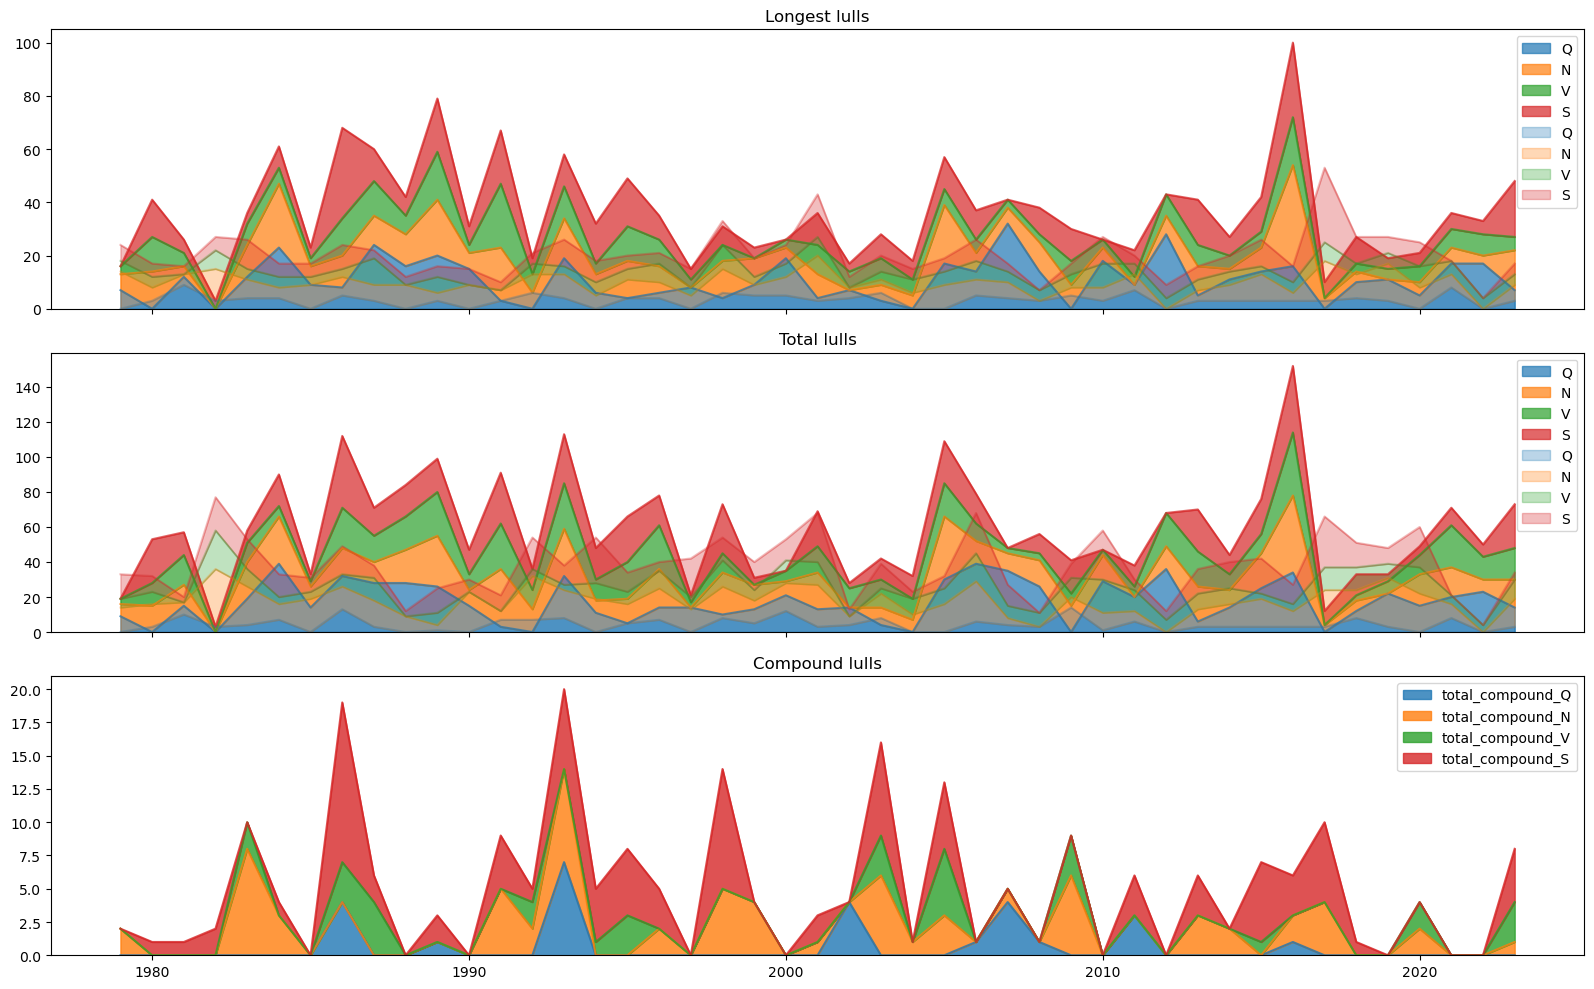

In [121]:
regions = ["Q", "N", "V", "S"]

colors = {
    "Q": "tab:blue",
    "N": "tab:orange",
    "V": "tab:green",
    "S": "tab:red",
}

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

plots = [
    ("longest", axes[0], "Longest lulls"),
    ("total", axes[1], "Total lulls"),
    ("total_compound", axes[2], "Compound lulls"),
]

for prefix, ax, title in plots:

    if prefix == "total_compound":
        cols = [f"total_compound_{r}" for r in regions]

        (
            df[cols]
            .rename(columns={f"compound_{r}": r for r in regions})
            .plot.area(
                ax=ax,
                color=[colors[r] for r in regions],
                alpha=0.8,
            )
        )

    else:
        solar_cols = [f"{prefix}_solar_{r}" for r in regions]
        wind_cols = [f"{prefix}_wind_{r}" for r in regions]

        (
            df[solar_cols]
            .rename(columns={f"{prefix}_solar_{r}": r for r in regions})
            .plot.area(
                ax=ax,
                color=[colors[r] for r in regions],
                alpha=0.7,
            )
        )

        (
            df[wind_cols]
            .rename(columns={f"{prefix}_wind_{r}": r for r in regions})
            .plot.area(
                ax=ax,
                color=[colors[r] for r in regions],
                alpha=0.3,
            )
        )

    ax.set_title(title)

fig.tight_layout()